### Q3. Working with Autoregressive Modeling [2 Marks]

- **[2 marks]**  Consider the [Daily Temperatures dataset](https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv) from Australia. This is a dataset for a forecasting task. That is, given temperatures up to date (or period) T, design a forecasting (autoregressive) model to predict the temperature on date T+1. You can refer to [link 1](https://www.turing.com/kb/guide-to-autoregressive-models), [link 2](https://otexts.com/fpp2/AR.html) for more information on autoregressive models. Use linear regression as your autoregressive model. Plot the fit of your predictions vs the true values and report the RMSE obtained. A demonstration of the plot is given below. ![imgsrc](./Autoregressive_Demo.png)

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [20]:
DATA_PATH = './data/daily_temperature.csv'

In [21]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
print(df.head())
print(df.tail())

(3650, 2)
         Date  Temp
0  1981-01-01  20.7
1  1981-01-02  17.9
2  1981-01-03  18.8
3  1981-01-04  14.6
4  1981-01-05  15.8
            Date  Temp
3645  1990-12-27  14.0
3646  1990-12-28  13.6
3647  1990-12-29  13.5
3648  1990-12-30  15.7
3649  1990-12-31  13.0


In [22]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3650 non-null   object 
 1   Temp    3650 non-null   float64
dtypes: float64(1), object(1)
memory usage: 57.2+ KB
None


In [23]:
print(df.describe())

              Temp
count  3650.000000
mean     11.177753
std       4.071837
min       0.000000
25%       8.300000
50%      11.000000
75%      14.000000
max      26.300000


#### autoregressive model implementation

In [24]:
temperatures = df['Temp'].values
print(f"Total temperature observations: {len(temperatures)}")

Total temperature observations: 3650


In [25]:
# Create autoregressive features
# Using lag features: T, T-1, T-2, ... to predict T+1

def create_ar_features(data, n_lags=5):
    X, y = [], []
    for i in range(n_lags, len(data)):
        X.append(data[i-n_lags:i])
        y.append(data[i])
    return np.array(X), np.array(y)


n_lags = 7
X, y = create_ar_features(temperatures, n_lags)
print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")


Feature matrix shape: (3643, 7)
Target vector shape: (3643,)


In [26]:
# Split data: 80% train, 20% test

train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")


Training samples: 2914
Test samples: 729


In [27]:
# Linear Regression using normal equation: theta = (X^T X)^-1 X^T y

# Add bias term
X_train_bias = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_bias = np.c_[np.ones(X_test.shape[0]), X_test]

# Compute parameters using normal equation
theta = np.linalg.inv(X_train_bias.T @ X_train_bias) @ X_train_bias.T @ y_train
print(f"Model parameters (theta): {theta}")
print(f"Intercept: {theta[0]:.4f}")
print(f"Coefficients: {theta[1:]}")


Model parameters (theta): [ 1.17439726  0.10071581  0.04531409  0.06850575  0.05750657  0.0773887
 -0.07338381  0.61790682]
Intercept: 1.1744
Coefficients: [ 0.10071581  0.04531409  0.06850575  0.05750657  0.0773887  -0.07338381
  0.61790682]


In [28]:
# Make predictions
y_train_pred = X_train_bias @ theta
y_test_pred = X_test_bias @ theta

# Calculate RMSE
train_rmse = np.sqrt(np.mean((y_train - y_train_pred)**2))
test_rmse = np.sqrt(np.mean((y_test - y_test_pred)**2))

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")


Train RMSE: 2.4877
Test RMSE: 2.2413


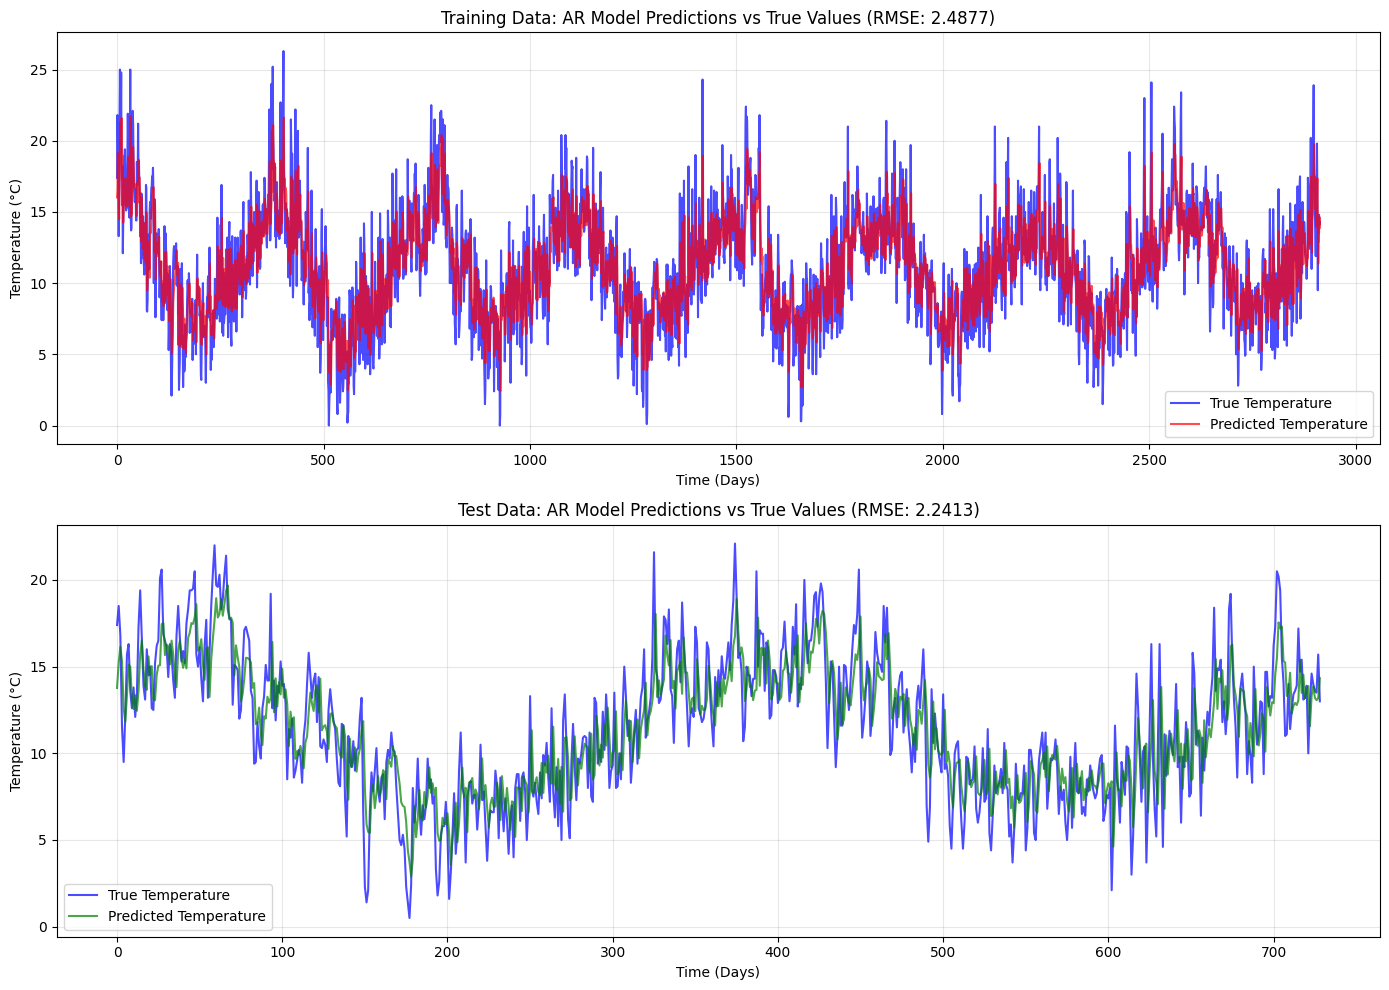

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Training data
axes[0].plot(range(len(y_train)), y_train, 'b-', label='True Temperature', alpha=0.7)
axes[0].plot(range(len(y_train_pred)), y_train_pred, 'r-', label='Predicted Temperature', alpha=0.7)
axes[0].set_xlabel('Time (Days)')
axes[0].set_ylabel('Temperature (°C)')
axes[0].set_title(f'Training Data: AR Model Predictions vs True Values (RMSE: {train_rmse:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test data
axes[1].plot(range(len(y_test)), y_test, 'b-', label='True Temperature', alpha=0.7)
axes[1].plot(range(len(y_test_pred)), y_test_pred, 'g-', label='Predicted Temperature', alpha=0.7)
axes[1].set_xlabel('Time (Days)')
axes[1].set_ylabel('Temperature (°C)')
axes[1].set_title(f'Test Data: AR Model Predictions vs True Values (RMSE: {test_rmse:.4f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


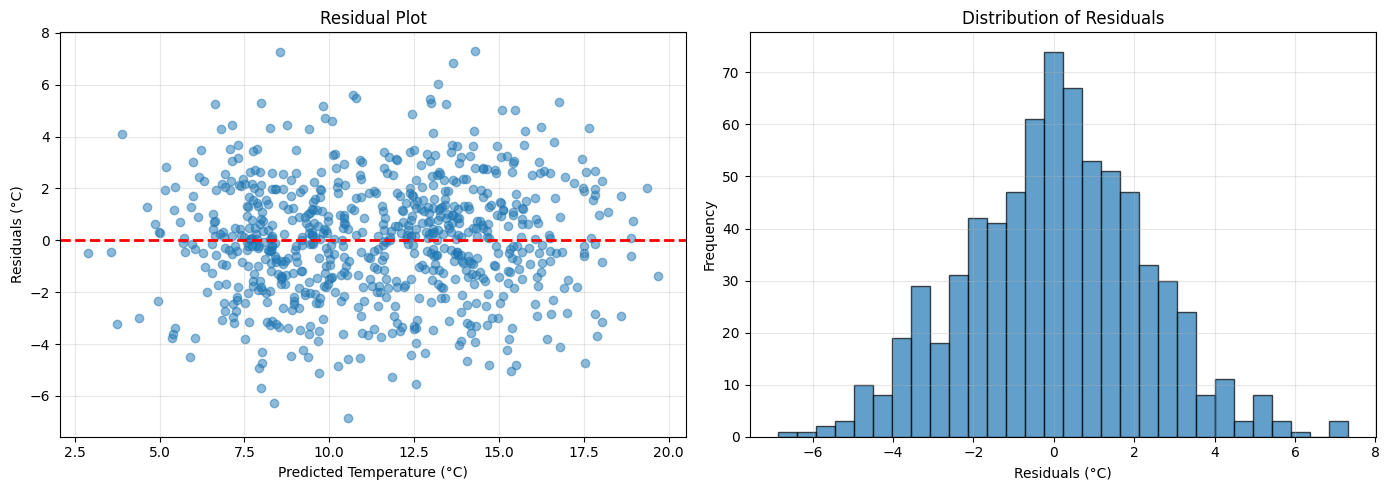

In [30]:
# providing more insights using residual analysis
test_residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual plot
axes[0].scatter(y_test_pred, test_residuals, alpha=0.5)
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Temperature (°C)')
axes[0].set_ylabel('Residuals (°C)')
axes[0].set_title('Residual Plot')
axes[0].grid(True, alpha=0.3)

# Histogram of residuals
axes[1].hist(test_residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residuals (°C)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### final stats

In [31]:
print(f"Number of lag features used: {n_lags}")
print(f"Training RMSE: {train_rmse:.4f}°C")
print(f"Test RMSE: {test_rmse:.4f}°C")
print(f"Mean Residual: {np.mean(test_residuals):.4f}°C")
print(f"Std Residual: {np.std(test_residuals):.4f}°C")

Number of lag features used: 7
Training RMSE: 2.4877°C
Test RMSE: 2.2413°C
Mean Residual: 0.0407°C
Std Residual: 2.2409°C
